# KI/NUM — zápočtová úloha č. 1

**Jiří Škvor**

---

## Zadání

Mějte soustavu lineárních rovnic $A\vec{x} = \vec{b}$, kde prvky matice $A$ jsou určeny vztahem

$$A_{ij} = \int_0^1 t^{i+j-2} \, dt \quad \text{pro } i, j = 1, \dots, N$$

a prvky vektoru pravých stran $\vec{b}$ jsou určeny vztahem

$$b_i = \sum_{j=1}^{N} A_{ij} \quad \text{pro } i = 1, \dots, N$$

Potřebné hodnoty určitého integrálu vypočítejte libovolnou **numerickou metodou** (vlastní implementace — ne analyticky, ne `scipy.integrate`).

Úlohu řešte pro počet neznámých $N = 2, \dots, 20$.

---

## Požadavky

1. **Sestavení matice $A$** — každý prvek $A_{ij}$ vypočítejte numerickou integrací vlastní implementací (Simpson, lichoběžník, Gauss — cokoliv z repozitáře).

2. **Řešení soustavy** — použijte vlastní solver ze svého repozitáře (Gaussova eliminace, LU rozklad nebo varianta s pivotací). Knihovní `numpy.linalg.solve` není povoleno jako primární solver.

3. **Ověření analytického řešení** — ukažte (matematicky nebo kódem), proč je $\vec{x} = \vec{1}$ analytickým řešením této soustavy pro libovolné $N$.

4. **Chyba řešení** — pro každé $N$ spočítejte

$$\varepsilon(N) = \|\vec{x} - \vec{1}\|_\infty = \max_{i} |x_i - 1|$$

5. **Graf** — vykreslete $\varepsilon(N)$ jako funkci $N$ (osa $x$: hodnoty $N = 2, \dots, 20$, osa $y$: chyba v logaritmickém měřítku).

6. **Komentář** — okomentujte slovně, co se děje s chybou jak roste $N$ a proč. Nápověda: zamyslete se nad podmíněností matice $A$.

---

## Nápověda

- Analytická hodnota integrálu je $A_{ij} = \frac{1}{i+j-1}$ — tuto hodnotu **nepoužívejte** při výpočtu, ale můžete ji použít k ověření, že vaše numerická integrace funguje správně.
- Matice $A$ je tzv. **Hilbertova matice** — jedna z nejznámějších špatně podmíněných matic. Číslo podmíněnosti $\kappa(A)$ roste velmi rychle s $N$.
- Pro výpočet integrálu stačí $n = 1000$ podintervalů.

---

## Odevzdání

- Jeden `.py` soubor (nebo `.ipynb`) s komentáři
- Graf chyby jako součást výstupu skriptu
- Slovní komentář ke kondici matice (stačí pár vět v kódu jako `# komentář`)

[[1.0000000000000002, 0.9999999999999993], [1.0000000000000044, 0.9999999999999761, 1.0000000000000224], [1.0000000000000153, 0.9999999999998309, 1.0000000000003963, 0.9999999999997474], [1.0000000000001394, 0.9999999999974238, 1.0000000000110103, 0.9999999999834882, 1.0000000000080325], [0.9999999999994766, 1.000000000014197, 0.9999999999070703, 1.0000000002360154, 0.9999999997441895, 1.000000000099356], [1.0000000000023155, 0.9999999999008383, 1.000000001004397, 0.9999999959467755, 1.0000000076481483, 0.9999999932378475, 1.000000002262179], [1.0000000000138274, 0.999999999273693, 1.000000009360231, 0.9999999498105063, 1.0000001341994418, 0.999999811116371, 1.0000001338526796, 0.9999999623642193], [0.999999999917321, 1.0000000057841143, 0.9999999008226927, 1.00000071620656, 0.9999973464423942, 1.0000054657514525, 0.9999936746803482, 1.0000038462927696, 0.999999044033746], [0.999999999417289, 1.0000000500717712, 0.9999989372958574, 1.0000096370854699, 0.9999541173757235, 1.000125950789

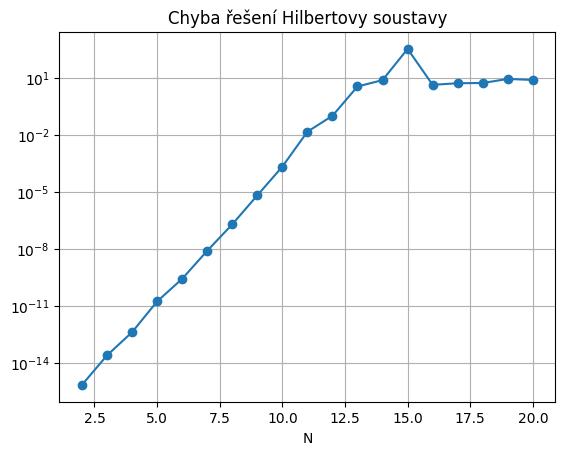

In [63]:
def simpson_rule(f, a, b, n):
    """
    Numerický výpočet integrálu pomocí Simpsonova pravidla.
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (musí být sudé a >= 2)
    :return: Přibližná hodnota integrálu
    """
    # Simpson vyžaduje sudý počet intervalů (n+1 bodů)
    if n < 2 or n % 2 != 0:
        print("Chyba: n musí být sudé a >= 2.")
        return None

    h = (b - a) / n
    # Začneme součtem krajních hodnot f(a) + f(b)
    total_sum = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        # Body v lichých pozicích se násobí 4, v sudých 2
        if i % 2 == 0:
            total_sum += 2 * f(x)
        else:
            total_sum += 4 * f(x)

    # Konečný vzorec: (h/3) * (f(a) + 4*f(x1) + 2*f(x2) + 4*f(x3) + ... + f(b))
    approximation = (h / 3) * total_sum
    return approximation


def gauss(a, b):
    """
    Řešení soustavy lineárních rovnic Ax = b pomocí Gaussovy eliminace.

    :param a: Matice soustavy (seznam seznamů, čtvercová n×n)
    :param b: Vektor pravé strany (délka n)
    :return: Vektor řešení x nebo None při selhání
    """
    n = len(b)
    
    # Kontrola rozměrů (čtvercová matice)
    if n != len(a) or any(len(row) != n for row in a):
        print("Chyba: Nesouhlasí délky vstupních dat.")
        return None

    # Vytvoření rozšířené matice (Bind v Go)
    # V Pythonu vytvoříme kopii, abychom nezměnili původní data
    ab = []
    for i in range(n):
        ab.append(list(a[i]) + [b[i]])

    # 1. Přímý chod (vytvoření horní trojúhelníkové matice)
    for k in range(n - 1):
        # Poznámka: V praxi by zde měl být "pivoting" (prohození řádků), 
        # aby ab[k][k] nebylo nula.
        for i in range(k + 1, n):
            c = -ab[i][k] / ab[k][k]
            for j in range(k, n + 1):
                ab[i][j] += c * ab[k][j]

    # 2. Zpětný chod (výpočet hodnot neznámých x)
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        sum_val = ab[i][n]
        for j in range(i + 1, n):
            sum_val -= ab[i][j] * x[j]
        
        x[i] = sum_val / ab[i][i]
        
    return x


def build_matrix(N):
    """
    Sestaví matici A (N×N) kde A[i][j] = 1 - 1/(i+j+1).
    Výjimka: A[0][0] = 0 (i+j+1=1, výsledek 1-1/1=0).

    :param N: Rozměr matice
    :return: Matice A jako seznam seznamů
    """
    A = []
    for i in range(1,N+1):
        row = []
        for j in range(1,N+1):
            if i == 0 and j == 0:
                row.append(0.0) 
            else:
                row.append(simpson_rule((lambda t: t**(i+j-2)),0,1,100))
        A.append(row)
    return A






celkove_chyby = []
celkove_reseni = []

for N in range(2,21):
    matr = build_matrix(N)
    b = []
    for row in matr:
        b.append(sum(row))
    reseni = gauss(matr,b)
    celkove_reseni.append(reseni)
    chyba = max(abs(x - 1.0) for x in reseni)
    celkove_chyby.append(chyba)

print(celkove_reseni)
print(celkove_chyby)
print(len(celkove_reseni))
print(len(celkove_chyby))


# matr = build_matrix(20)
# print(matr)
# print(len(matr))


# b = []
# for row in matr:
#     b.append(sum(row))

# print(b)
# print(len(b))

# reseni = gauss(matr,b)

# print(reseni)



import matplotlib.pyplot as plt

plt.semilogy(range(2, 21), celkove_chyby, marker='o')
plt.xlabel("N")
plt.title("Chyba řešení Hilbertovy soustavy")
plt.grid(True)
plt.show()




